# Notebook 09 — ABM Design & Calibration

## Patient Similarity Network + Agent-Based Modelling for Readmission

### Purpose
Build the **first executable, deliberately simple agent-based model** for patient readmission.

This notebook follows the project proposal:
- each agent represents one patient;
- agent state contains clinical profile, utilization history, baseline risk, network information, intervention state, and outcome state;
- the first ABM uses a **probabilistic readmission transition**, rather than inventing a detailed physiological disease process;
- transition probabilities are calibrated from training/validation information;
- stochastic behaviour is controlled by an explicit seed;
- every transition rule is unit-tested;
- tiny hand-checkable simulations are used before scaling to the full training population.

### Important methodological rule
This is a **clinical/patient similarity network**, not a social network.

The readmission outcome is never used to construct the similarity network or to define network edges.

### Notebook 09 does NOT perform intervention experiments
Intervention comparison belongs to Notebook 11. Here we only establish and validate the natural/no-intervention ABM mechanics and calibration.


## Inputs from previous notebooks

Expected files in `sna/results/`:

- Notebook 04 train/validation/test patient IDs and targets
- Notebook 05 feature matrices and patient IDs
- Notebook 06 patient similarity network edge/node files
- Notebook 07 SNA node-level results and community labels
- Notebook 08 baseline test/prediction outputs

### Data-use rule

The final test set is **not used for ABM calibration**.

Calibration uses training information, with validation used for checking/calibration decisions where possible. The final test population remains reserved for later evaluation after the pipeline is frozen.


In [1]:
# ============================================================
# 1. Imports and reproducibility
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy import sparse

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

print("ABM seed:", SEED)


ABM seed: 42


In [2]:
# ============================================================
# 2. Locate project root
# ============================================================

def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path.cwd().parent.parent.parent,
    ]

    for start in candidates:
        start = start.resolve()

        for root in [start, *start.parents]:
            results = root / "results"

            if (
                (results / "06_patient_similarity_edges_k10.csv").exists()
                and (results / "07_sna_summary.json").exists()
                and (results / "08_test_predictions.csv").exists()
            ):
                return root

    return None


PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the sna project. "
        "Open this notebook inside the sna project folder."
    )

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)


PROJECT_ROOT: C:\Users\Gayatri\OneDrive\Desktop\sna
RESULTS_DIR: C:\Users\Gayatri\OneDrive\Desktop\sna\results


In [3]:
# ============================================================
# 3. Locate expected files
# ============================================================

def first_existing(names, required=True):
    for name in names:
        path = RESULTS_DIR / name
        if path.exists():
            return path

    if required:
        raise FileNotFoundError(
            "Could not find any of: " + ", ".join(names)
        )

    return None


TRAIN_IDS_PATH = first_existing([
    "04_train_patient_ids.csv"
])

VALID_IDS_PATH = first_existing([
    "04_validation_patient_ids.csv"
])

TEST_IDS_PATH = first_existing([
    "04_test_patient_ids.csv"
])

TRAIN_FEATURE_IDS_PATH = first_existing([
    "05_train_feature_patient_ids.csv"
])

VALID_FEATURE_IDS_PATH = first_existing([
    "05_validation_feature_patient_ids.csv"
])

TEST_FEATURE_IDS_PATH = first_existing([
    "05_test_feature_patient_ids.csv"
])

EDGE_PATH = first_existing([
    "06_patient_similarity_edges_k10.csv",
    "06_patient_similarity_edges_k10.csv"
])

NODE_PATH = first_existing([
    "06_patient_similarity_nodes.csv"
])

SNA_SUMMARY_PATH = first_existing([
    "07_sna_summary.json"
])

SNA_FEATURES_PATH = first_existing([
    "07_sna_features.csv",
    "07_centrality.csv",
    "07_sna_node_features.csv"
], required=False)

TEST_PREDICTIONS_PATH = first_existing([
    "08_test_predictions.csv"
])

print("All required ABM input files located.")


All required ABM input files located.


In [4]:
# ============================================================
# 4. Load patient IDs
# ============================================================

def read_patient_ids(path):
    df = pd.read_csv(path)

    if "patient_nbr" not in df.columns:
        raise ValueError(f"{path.name} has no patient_nbr column.")

    ids = df["patient_nbr"].astype(int)

    if not ids.is_unique:
        raise AssertionError(f"Duplicate patient IDs found in {path.name}.")

    return ids


train_ids = read_patient_ids(TRAIN_IDS_PATH)
valid_ids = read_patient_ids(VALID_IDS_PATH)
test_ids = read_patient_ids(TEST_IDS_PATH)

train_id_set = set(train_ids)
valid_id_set = set(valid_ids)
test_id_set = set(test_ids)

print("Train:", len(train_ids))
print("Validation:", len(valid_ids))
print("Test:", len(test_ids))

assert train_id_set.isdisjoint(valid_id_set)
assert train_id_set.isdisjoint(test_id_set)
assert valid_id_set.isdisjoint(test_id_set)

print("Patient split integrity: PASS")


Train: 50062
Validation: 10728
Test: 10728
Patient split integrity: PASS


In [5]:
# ============================================================
# 5. Load Notebook 05 feature matrices
# ============================================================

X_train = sparse.load_npz(
    RESULTS_DIR / "05_X_train.npz"
).tocsr()

X_valid = sparse.load_npz(
    RESULTS_DIR / "05_X_validation.npz"
).tocsr()

X_test = sparse.load_npz(
    RESULTS_DIR / "05_X_test.npz"
).tocsr()

train_feature_ids = read_patient_ids(TRAIN_FEATURE_IDS_PATH)
valid_feature_ids = read_patient_ids(VALID_FEATURE_IDS_PATH)
test_feature_ids = read_patient_ids(TEST_FEATURE_IDS_PATH)

assert list(train_feature_ids) == list(train_ids)
assert list(valid_feature_ids) == list(valid_ids)
assert list(test_feature_ids) == list(test_ids)

assert X_train.shape[0] == len(train_ids)
assert X_valid.shape[0] == len(valid_ids)
assert X_test.shape[0] == len(test_ids)

assert X_train.shape[1] == X_valid.shape[1] == X_test.shape[1]

print("Feature dimensions:", X_train.shape[1])
print("Patient-feature alignment: PASS")


Feature dimensions: 57
Patient-feature alignment: PASS


In [6]:
# ============================================================
# 6. Load Notebook 04 targets
# ============================================================

def load_primary_target(split_name, expected_ids):
    candidates = [
        RESULTS_DIR / f"04_{split_name}.csv",
        RESULTS_DIR / f"04_{split_name}_patients.csv",
        RESULTS_DIR / f"04_{split_name}_patient_targets.csv",
    ]

    path = next((p for p in candidates if p.exists()), None)

    if path is None:
        raise FileNotFoundError(
            f"No target file found for {split_name}."
        )

    df = pd.read_csv(path)

    target_candidates = [
        "any_observed_readmission_under_30d",
        "primary_target",
        "target",
        "readmission_target",
    ]

    target_col = next(
        (c for c in target_candidates if c in df.columns),
        None
    )

    if target_col is None:
        raise ValueError(
            f"No primary target found in {path.name}. "
            f"Columns: {list(df.columns)}"
        )

    out = df[["patient_nbr", target_col]].copy()
    out["patient_nbr"] = out["patient_nbr"].astype(int)
    out = out.rename(columns={target_col: "target"})
    out["target"] = pd.to_numeric(out["target"], errors="raise").astype(int)

    if set(out["patient_nbr"]) != set(expected_ids):
        raise AssertionError(
            f"Target IDs do not match expected {split_name} IDs."
        )

    out = (
        pd.DataFrame({"patient_nbr": expected_ids.astype(int)})
        .merge(
            out,
            on="patient_nbr",
            how="left",
            validate="one_to_one"
        )
    )

    return out, path


train_target_df, train_target_path = load_primary_target(
    "train", train_ids
)

valid_target_df, valid_target_path = load_primary_target(
    "validation", valid_ids
)

test_target_df, test_target_path = load_primary_target(
    "test", test_ids
)

y_train = train_target_df["target"].to_numpy()
y_valid = valid_target_df["target"].to_numpy()
y_test = test_target_df["target"].to_numpy()

print("Primary target:", "any_observed_readmission_under_30d")
print("Train prevalence:", round(float(y_train.mean()), 6))
print("Validation prevalence:", round(float(y_valid.mean()), 6))
print("Test prevalence:", round(float(y_test.mean()), 6))


Primary target: any_observed_readmission_under_30d
Train prevalence: 0.123527
Validation prevalence: 0.123509
Test prevalence: 0.123509


In [7]:
# ============================================================
# 7. Load baseline risk predictions
# ============================================================

# Notebook 08 contains test predictions. For ABM calibration we need
# risk estimates for train/validation patients without using test data.
#
# Therefore we train a small calibration-only logistic model using
# the already-created Notebook 05 matrices. This is not the Notebook
# 08 final model and is used only to produce continuous baseline risk
# for the ABM state.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

risk_model = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=SEED
)

risk_model.fit(X_train, y_train)

risk_train = risk_model.predict_proba(X_train)[:, 1]
risk_valid = risk_model.predict_proba(X_valid)[:, 1]

print("Calibration-only risk model fitted.")
print("Train risk range:", float(risk_train.min()), float(risk_train.max()))
print("Validation risk range:", float(risk_valid.min()), float(risk_valid.max()))

print(
    "Validation risk AUROC:",
    round(float(roc_auc_score(y_valid, risk_valid)), 6)
)

print(
    "Validation risk Brier:",
    round(float(brier_score_loss(y_valid, risk_valid)), 6)
)

assert np.isfinite(risk_train).all()
assert np.isfinite(risk_valid).all()
assert ((risk_train >= 0) & (risk_train <= 1)).all()
assert ((risk_valid >= 0) & (risk_valid <= 1)).all()


Calibration-only risk model fitted.
Train risk range: 9.747148991816956e-06 0.9999994593918071
Validation risk range: 3.873415578332414e-07 0.9999118546670438
Validation risk AUROC: 0.870751
Validation risk Brier: 0.075091


## 8. ABM agent state

Each patient agent contains:

| State | Meaning |
|---|---|
| `patient_nbr` | Anonymized patient identifier |
| `clinical_state` | Patient feature vector |
| `utilization_state` | Patient-level utilization representation |
| `risk_state` | Baseline readmission probability |
| `neighbors` | Similar patients in the clinical similarity network |
| `weighted_degree` | Sum of similarity weights |
| `community` | SNA community when available |
| `intervention_state` | Initially `none` |
| `outcome_state` | `stable`, `readmitted`, or `terminal` |
| `time_step` | Simulation step |

The first model has only a small number of transition rules. This keeps the simulation interpretable and testable.


In [8]:
# ============================================================
# 9. Load similarity network
# ============================================================

edges = pd.read_csv(EDGE_PATH)
nodes = pd.read_csv(NODE_PATH)

print("Edges:", edges.shape)
print("Nodes:", nodes.shape)

# Resolve column names robustly.
source_col = next(
    (c for c in ["source_patient_nbr", "source", "patient_nbr_source"] if c in edges.columns),
    None
)

target_col = next(
    (c for c in ["target_patient_nbr", "target", "patient_nbr_target"] if c in edges.columns),
    None
)

weight_col = next(
    (c for c in ["similarity", "weight", "edge_weight"] if c in edges.columns),
    None
)

if not all([source_col, target_col, weight_col]):
    raise ValueError(
        f"Could not resolve edge columns in {list(edges.columns)}"
    )

node_id_col = "patient_nbr"

G = nx.Graph()

G.add_nodes_from(nodes[node_id_col].astype(int).tolist())

for row in edges.itertuples(index=False):
    u = int(getattr(row, source_col))
    v = int(getattr(row, target_col))
    w = float(getattr(row, weight_col))

    if u != v:
        G.add_edge(u, v, weight=w)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G))

assert nx.number_of_selfloops(G) == 0
assert set(G.nodes()).issubset(train_id_set)

print("Network contains training patients only: PASS")


Edges: (434595, 5)
Nodes: (50062, 3)
Graph nodes: 50062
Graph edges: 434595
Self-loops: 0
Network contains training patients only: PASS


In [9]:
# ============================================================
# 10. Load SNA community information when available
# ============================================================

sna_summary = json.loads(
    SNA_SUMMARY_PATH.read_text(encoding="utf-8")
)

print("SNA community method:", sna_summary.get("community_method"))
print("SNA community count:", sna_summary.get("community_count"))

community_map = {}

if SNA_FEATURES_PATH is not None:

    sna_df = pd.read_csv(SNA_FEATURES_PATH)

    if "patient_nbr" in sna_df.columns:

        community_col = next(
            (
                c for c in sna_df.columns
                if "community" in c.lower()
            ),
            None
        )

        if community_col is not None:
            community_map = dict(
                zip(
                    sna_df["patient_nbr"].astype(int),
                    sna_df[community_col]
                )
            )

print("Community assignments available:", len(community_map))


SNA community method: louvain
SNA community count: 105
Community assignments available: 50062


In [10]:
# ============================================================
# 11. Build agent records
# ============================================================

weighted_degree = dict(G.degree(weight="weight"))

agent_table = pd.DataFrame({
    "patient_nbr": train_ids.astype(int),
    "risk_state": risk_train,
})

agent_table["degree"] = (
    agent_table["patient_nbr"]
    .map(dict(G.degree()))
    .fillna(0)
    .astype(int)
)

agent_table["weighted_degree"] = (
    agent_table["patient_nbr"]
    .map(weighted_degree)
    .fillna(0.0)
    .astype(float)
)

agent_table["community"] = (
    agent_table["patient_nbr"]
    .map(community_map)
    .fillna(-1)
)

agent_table["intervention_state"] = "none"
agent_table["outcome_state"] = "stable"
agent_table["time_step"] = 0

print(agent_table.head())
print("\nAgent count:", len(agent_table))

assert len(agent_table) == len(train_ids)
assert agent_table["patient_nbr"].is_unique
assert np.isfinite(agent_table["risk_state"]).all()
assert (agent_table["risk_state"].between(0, 1)).all()


   patient_nbr  risk_state  degree  weighted_degree  community  \
0          135    0.262512      26        23.898220          1   
1          378    0.027779      23        21.696827          7   
2          729    0.044727      13        11.734949          3   
3          927    0.021810      30        28.646146         13   
4         1152    0.674279       2         1.765701          5   

  intervention_state outcome_state  time_step  
0               none        stable          0  
1               none        stable          0  
2               none        stable          0  
3               none        stable          0  
4               none        stable          0  

Agent count: 50062


## 12. Transition model

The first ABM uses a deliberately simple transition:

### Stable → Readmitted

At each simulation step:

\[
P(\text{readmission}) =
\operatorname{clip}(r_i \times M, 0, 1)
\]

where:
- `r_i` is the patient's baseline risk state;
- `M` is a calibration multiplier.

This preserves the individual risk ordering while allowing the simulation to be calibrated to an aggregate observed readmission proportion.

### Readmitted → Terminal

Once an agent is readmitted, the simple first ABM marks the outcome as terminal for this simulation horizon.

### Intervention state

Notebook 09 starts with `intervention_state = none`.

Intervention effects are deliberately **not** introduced here; they belong to Notebook 11.


In [11]:
# ============================================================
# 13. Calibration of natural transition probability
# ============================================================

# We need a simple aggregate calibration multiplier.
# The multiplier is fitted on TRAINING observations only.
#
# For each multiplier, expected aggregate probability is:
# mean(clip(risk * multiplier, 0, 1))
#
# Choose the multiplier whose expected mean probability is closest
# to the observed training prevalence.

observed_train_rate = float(y_train.mean())

candidate_multipliers = np.linspace(
    0.1,
    5.0,
    491
)

calibration_rows = []

for multiplier in candidate_multipliers:

    simulated_probability = np.clip(
        risk_train * multiplier,
        0,
        1
    )

    calibration_rows.append({
        "multiplier": float(multiplier),
        "expected_readmission_rate": float(
            simulated_probability.mean()
        ),
        "absolute_error": float(
            abs(simulated_probability.mean() - observed_train_rate)
        )
    })

calibration_table = pd.DataFrame(calibration_rows)

best_calibration = calibration_table.sort_values(
    "absolute_error"
).iloc[0]

CALIBRATION_MULTIPLIER = float(
    best_calibration["multiplier"]
)

print("Observed training readmission rate:",
      round(observed_train_rate, 6))

print("Selected calibration multiplier:",
      CALIBRATION_MULTIPLIER)

print("Expected calibrated rate:",
      round(
          float(best_calibration["expected_readmission_rate"]),
          6
      ))

print("Calibration absolute error:",
      round(
          float(best_calibration["absolute_error"]),
          6
      ))

assert CALIBRATION_MULTIPLIER > 0


Observed training readmission rate: 0.123527
Selected calibration multiplier: 1.0
Expected calibrated rate: 0.123544
Calibration absolute error: 1.7e-05


In [12]:
# ============================================================
# 14. Define transition functions
# ============================================================

def transition_probability(
    baseline_risk,
    multiplier=CALIBRATION_MULTIPLIER,
    intervention_effect=0.0
):
    """Return bounded probability of readmission.

    intervention_effect is kept at 0 in Notebook 09.
    Notebook 11 will introduce intervention effectiveness.
    """

    probability = (
        float(baseline_risk)
        * float(multiplier)
        * (1.0 - float(intervention_effect))
    )

    return float(np.clip(probability, 0.0, 1.0))


def stable_to_readmitted(
    baseline_risk,
    rng,
    multiplier=CALIBRATION_MULTIPLIER,
    intervention_effect=0.0
):
    """One Bernoulli transition from stable to readmitted."""

    p = transition_probability(
        baseline_risk,
        multiplier=multiplier,
        intervention_effect=intervention_effect
    )

    draw = float(rng.random())

    return {
        "probability": p,
        "random_draw": draw,
        "new_state": "readmitted" if draw < p else "stable"
    }


def readmitted_to_terminal():
    """Readmitted state is terminal for this first simulation horizon."""

    return "terminal"


def advance_agent(agent, rng):
    """Advance one agent by one simulation step."""

    if agent["outcome_state"] == "terminal":
        return agent

    if agent["outcome_state"] == "readmitted":
        agent["outcome_state"] = "terminal"
        agent["time_step"] += 1
        return agent

    result = stable_to_readmitted(
        agent["risk_state"],
        rng
    )

    agent["outcome_state"] = result["new_state"]
    agent["time_step"] += 1

    return agent


print("Transition functions defined.")


Transition functions defined.


# 15. Unit tests — transition rules

These tests are deliberately deterministic.

The proposal requires every transition rule to be unit-tested before full simulation. If these tests fail, the ABM must not proceed.


In [13]:
# ============================================================
# 16. Unit tests
# ============================================================

# Test 1: probability is always bounded.
test_risks = np.linspace(0, 1, 101)

test_probabilities = [
    transition_probability(r)
    for r in test_risks
]

assert all(
    0 <= p <= 1
    for p in test_probabilities
)

print("PASS | probability bounded in [0,1]")


# Test 2: zero risk can never readmit.
zero_rng = np.random.default_rng(SEED)

for _ in range(100):
    result = stable_to_readmitted(
        0.0,
        zero_rng
    )
    assert result["new_state"] == "stable"

print("PASS | zero-risk transition never readmits")


# Test 3: probability 1 must always readmit.
one_rng = np.random.default_rng(SEED)

for _ in range(100):
    result = stable_to_readmitted(
        1.0,
        one_rng,
        multiplier=1.0
    )
    assert result["new_state"] == "readmitted"

print("PASS | probability-1 transition always readmits")


# Test 4: readmitted becomes terminal.
assert readmitted_to_terminal() == "terminal"

print("PASS | readmitted -> terminal")


# Test 5: terminal state remains terminal.
terminal_agent = {
    "patient_nbr": 1,
    "risk_state": 0.5,
    "outcome_state": "terminal",
    "time_step": 3,
}

terminal_rng = np.random.default_rng(SEED)

advanced = advance_agent(
    terminal_agent.copy(),
    terminal_rng
)

assert advanced["outcome_state"] == "terminal"

print("PASS | terminal state remains terminal")


# Test 6: stable agent advances exactly one step.
stable_agent = {
    "patient_nbr": 2,
    "risk_state": 0.0,
    "outcome_state": "stable",
    "time_step": 0,
}

advanced = advance_agent(
    stable_agent.copy(),
    np.random.default_rng(SEED)
)

assert advanced["time_step"] == 1
assert advanced["outcome_state"] == "stable"

print("PASS | stable agent advances one step")


print("\nALL TRANSITION UNIT TESTS: PASS")


PASS | probability bounded in [0,1]
PASS | zero-risk transition never readmits
PASS | probability-1 transition always readmits
PASS | readmitted -> terminal
PASS | terminal state remains terminal
PASS | stable agent advances one step

ALL TRANSITION UNIT TESTS: PASS


## 17. Tiny hand-checkable simulation

Before using thousands of agents, test the ABM with five agents whose risks are explicitly known.

The simulation is intentionally simple:
- same calibration multiplier;
- same initial states;
- fixed seed;
- one simulation step;
- every random draw is recorded.

This makes the result reproducible and manually inspectable.


In [14]:
# ============================================================
# 18. Five-agent hand-checkable simulation
# ============================================================

tiny_agents = pd.DataFrame({
    "patient_nbr": [101, 102, 103, 104, 105],
    "risk_state": [0.0, 0.25, 0.50, 0.75, 1.0],
    "outcome_state": ["stable"] * 5,
    "time_step": [0] * 5,
})

tiny_rng = np.random.default_rng(SEED)

tiny_records = []

for _, row in tiny_agents.iterrows():

    result = stable_to_readmitted(
        float(row["risk_state"]),
        tiny_rng,
        multiplier=1.0
    )

    tiny_records.append({
        "patient_nbr": int(row["patient_nbr"]),
        "risk_state": float(row["risk_state"]),
        "probability": float(result["probability"]),
        "random_draw": float(result["random_draw"]),
        "outcome_state": result["new_state"],
    })

tiny_result = pd.DataFrame(tiny_records)

display(tiny_result)

assert len(tiny_result) == 5
assert tiny_result["patient_nbr"].is_unique
assert tiny_result["probability"].between(0, 1).all()

# The first agent has probability 0 and therefore must remain stable.
assert tiny_result.loc[
    tiny_result["patient_nbr"] == 101,
    "outcome_state"
].iloc[0] == "stable"

# The final agent has probability 1 and therefore must readmit.
assert tiny_result.loc[
    tiny_result["patient_nbr"] == 105,
    "outcome_state"
].iloc[0] == "readmitted"

print("TINY SIMULATION: PASS")


,patient_nbr,risk_state,probability,random_draw,outcome_state
0,101,0.00,0.00,0.773956,stable
1,102,0.25,0.25,0.438878,stable
2,103,0.50,0.50,0.858598,stable
3,104,0.75,0.75,0.697368,readmitted
4,105,1.00,1.00,0.094177,readmitted


TINY SIMULATION: PASS


## 19. Reproducibility test

The same seed and same initial population must produce the same sequence of transitions.

This is essential because later intervention experiments will compare policies under identical stochastic conditions.


In [15]:
# ============================================================
# 20. Reproducibility test
# ============================================================

def run_tiny_simulation(seed):
    local_rng = np.random.default_rng(seed)

    records = []

    for _, row in tiny_agents.iterrows():

        result = stable_to_readmitted(
            float(row["risk_state"]),
            local_rng,
            multiplier=1.0
        )

        records.append([
            int(row["patient_nbr"]),
            float(result["random_draw"]),
            result["new_state"]
        ])

    return pd.DataFrame(
        records,
        columns=[
            "patient_nbr",
            "random_draw",
            "outcome_state"
        ]
    )


tiny_a = run_tiny_simulation(SEED)
tiny_b = run_tiny_simulation(SEED)

pd.testing.assert_frame_equal(
    tiny_a,
    tiny_b
)

print("PASS | same seed produces identical simulation")


PASS | same seed produces identical simulation


## 21. Full training-population natural trajectory

Now run one no-intervention simulation over the complete training population.

This is still a **calibration/mechanics run**, not the final intervention experiment.

For each training patient:
1. start stable;
2. use the patient's baseline risk;
3. calculate the calibrated transition probability;
4. draw one Bernoulli outcome;
5. record the result.

The validation population is then used to check whether the calibrated rule behaves reasonably on held-out patients.


In [16]:
# ============================================================
# 22. Full training simulation
# ============================================================

def simulate_population(
    patient_ids,
    risks,
    seed,
    multiplier=CALIBRATION_MULTIPLIER
):

    local_rng = np.random.default_rng(seed)

    records = []

    for patient_id, risk in zip(patient_ids, risks):

        result = stable_to_readmitted(
            float(risk),
            local_rng,
            multiplier=multiplier
        )

        records.append({
            "patient_nbr": int(patient_id),
            "baseline_risk": float(risk),
            "transition_probability": float(result["probability"]),
            "random_draw": float(result["random_draw"]),
            "outcome_state": result["new_state"],
            "intervention_state": "none",
            "time_step": 1,
        })

    return pd.DataFrame(records)


train_simulation = simulate_population(
    train_ids,
    risk_train,
    seed=SEED,
)

valid_simulation = simulate_population(
    valid_ids,
    risk_valid,
    seed=SEED,
)

print("Training simulated patients:", len(train_simulation))
print("Validation simulated patients:", len(valid_simulation))

print(
    "Training simulated readmission rate:",
    round(
        float(
            (train_simulation["outcome_state"] == "readmitted").mean()
        ),
        6
    )
)

print(
    "Validation simulated readmission rate:",
    round(
        float(
            (valid_simulation["outcome_state"] == "readmitted").mean()
        ),
        6
    )
)

assert len(train_simulation) == len(train_ids)
assert len(valid_simulation) == len(valid_ids)
assert train_simulation["patient_nbr"].is_unique
assert valid_simulation["patient_nbr"].is_unique


Training simulated patients: 50062
Validation simulated patients: 10728
Training simulated readmission rate: 0.124166
Validation simulated readmission rate: 0.12789


In [17]:
# ============================================================
# 23. Calibration diagnostics
# ============================================================

train_expected_rate = float(
    train_simulation["transition_probability"].mean()
)

train_observed_sim_rate = float(
    (train_simulation["outcome_state"] == "readmitted").mean()
)

valid_expected_rate = float(
    valid_simulation["transition_probability"].mean()
)

valid_observed_sim_rate = float(
    (valid_simulation["outcome_state"] == "readmitted").mean()
)

calibration_diagnostics = pd.DataFrame([
    {
        "population": "train",
        "observed_data_rate": observed_train_rate,
        "expected_abm_rate": train_expected_rate,
        "simulated_abm_rate": train_observed_sim_rate,
        "expected_minus_observed": train_expected_rate - observed_train_rate,
    },
    {
        "population": "validation",
        "observed_data_rate": float(y_valid.mean()),
        "expected_abm_rate": valid_expected_rate,
        "simulated_abm_rate": valid_observed_sim_rate,
        "expected_minus_observed": valid_expected_rate - float(y_valid.mean()),
    }
])

display(calibration_diagnostics)


,population,observed_data_rate,expected_abm_rate,simulated_abm_rate,expected_minus_observed
0,train,0.123527,0.123544,0.124166,0.000017
1,validation,0.123509,0.123423,0.127890,-0.000086


In [18]:
# ============================================================
# 24. Risk-bin calibration on validation data
# ============================================================

validation_calibration = pd.DataFrame({
    "patient_nbr": valid_ids.astype(int),
    "observed_target": y_valid.astype(int),
    "baseline_risk": risk_valid,
    "transition_probability": valid_simulation[
        "transition_probability"
    ].to_numpy(),
})

validation_calibration["risk_bin"] = pd.qcut(
    validation_calibration["baseline_risk"],
    q=10,
    duplicates="drop"
)

risk_bin_summary = (
    validation_calibration
    .groupby("risk_bin", observed=True)
    .agg(
        n=("patient_nbr", "size"),
        observed_readmission_rate=("observed_target", "mean"),
        mean_baseline_risk=("baseline_risk", "mean"),
        mean_transition_probability=("transition_probability", "mean"),
    )
    .reset_index()
)

display(risk_bin_summary)

assert len(risk_bin_summary) >= 5
assert np.isfinite(
    risk_bin_summary[
        [
            "observed_readmission_rate",
            "mean_baseline_risk",
            "mean_transition_probability"
        ]
    ].to_numpy()
).all()


,risk_bin,n,observed_readmission_rate,mean_baseline_risk,mean_transition_probability
0,"(-0.000999613, 0.0285]",1073,0.017707,0.023812,0.023812
1,"(0.0285, 0.0339]",1073,0.013979,0.031305,0.031305
2,"(0.0339, 0.0383]",1073,0.016775,0.036118,0.036118
3,"(0.0383, 0.0428]",1072,0.026119,0.040427,0.040427
4,"(0.0428, 0.0476]",1073,0.033551,0.045025,0.045025
5,"(0.0476, 0.0538]",1073,0.049394,0.050455,0.050455
6,"(0.0538, 0.0661]",1072,0.052239,0.058912,0.058912
7,"(0.0661, 0.158]",1073,0.108108,0.096328,0.096328
8,"(0.158, 0.301]",1073,0.326188,0.219517,0.219517
9,"(0.301, 1.0]",1073,0.590867,0.632192,0.632192


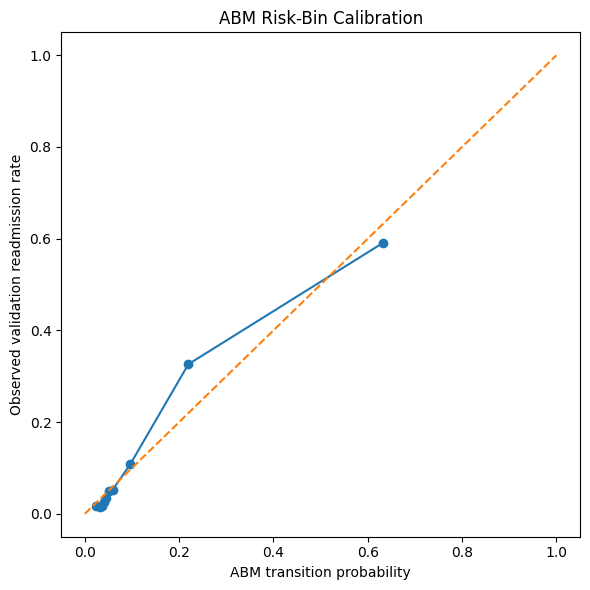

Saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\09_abm_risk_bin_calibration.png


In [19]:
# ============================================================
# 25. Calibration plot
# ============================================================

plt.figure(figsize=(6, 6))

plt.plot(
    risk_bin_summary["mean_transition_probability"],
    risk_bin_summary["observed_readmission_rate"],
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("ABM transition probability")
plt.ylabel("Observed validation readmission rate")
plt.title("ABM Risk-Bin Calibration")
plt.tight_layout()

ABM_CALIBRATION_FIG = (
    FIGURES_DIR / "09_abm_risk_bin_calibration.png"
)

plt.savefig(
    ABM_CALIBRATION_FIG,
    dpi=150
)

plt.show()

print("Saved:", ABM_CALIBRATION_FIG)


## 26. Network state audit

The network is included in the agent state so that Notebook 11 can later implement network-informed targeting.

However, **network centrality does not directly change the natural readmission transition in Notebook 09**.

This separation is intentional:
- clinical risk drives the baseline natural transition;
- network structure is stored as contextual agent state;
- intervention policies later decide how that state is used.


In [20]:
# ============================================================
# 27. Network-state coverage
# ============================================================

network_state_audit = pd.DataFrame({
    "patient_nbr": train_ids.astype(int),
})

network_state_audit["degree"] = (
    network_state_audit["patient_nbr"]
    .map(dict(G.degree()))
    .fillna(0)
)

network_state_audit["weighted_degree"] = (
    network_state_audit["patient_nbr"]
    .map(weighted_degree)
    .fillna(0)
)

network_state_audit["community"] = (
    network_state_audit["patient_nbr"]
    .map(community_map)
    .fillna(-1)
)

print("Training agents:", len(network_state_audit))
print(
    "Agents with at least one network neighbour:",
    int((network_state_audit["degree"] > 0).sum())
)

print(
    "Agents with no network neighbour:",
    int((network_state_audit["degree"] == 0).sum())
)

assert len(network_state_audit) == len(train_ids)
assert np.isfinite(
    network_state_audit[
        ["degree", "weighted_degree"]
    ].to_numpy()
).all()

assert (
    network_state_audit["degree"] >= 0
).all()

assert (
    network_state_audit["weighted_degree"] >= 0
).all()


Training agents: 50062
Agents with at least one network neighbour: 49985
Agents with no network neighbour: 77


In [21]:
# ============================================================
# 28. Save Notebook 09 outputs
# ============================================================

AGENT_STATE_OUTPUT = (
    RESULTS_DIR / "09_abm_agent_state.csv"
)

TRAIN_SIM_OUTPUT = (
    RESULTS_DIR / "09_abm_train_no_intervention.csv"
)

VALID_SIM_OUTPUT = (
    RESULTS_DIR / "09_abm_validation_no_intervention.csv"
)

CALIBRATION_OUTPUT = (
    RESULTS_DIR / "09_abm_calibration.csv"
)

RISK_BIN_OUTPUT = (
    RESULTS_DIR / "09_abm_validation_risk_bins.csv"
)

NETWORK_AUDIT_OUTPUT = (
    RESULTS_DIR / "09_abm_network_state_audit.csv"
)

CONFIG_OUTPUT = (
    RESULTS_DIR / "09_abm_config.json"
)

CHECKPOINT_OUTPUT = (
    RESULTS_DIR / "09_abm_checkpoint.json"
)

agent_table.to_csv(
    AGENT_STATE_OUTPUT,
    index=False
)

train_simulation.to_csv(
    TRAIN_SIM_OUTPUT,
    index=False
)

valid_simulation.to_csv(
    VALID_SIM_OUTPUT,
    index=False
)

calibration_diagnostics.to_csv(
    CALIBRATION_OUTPUT,
    index=False
)

risk_bin_summary.to_csv(
    RISK_BIN_OUTPUT,
    index=False
)

network_state_audit.to_csv(
    NETWORK_AUDIT_OUTPUT,
    index=False
)

config = {
    "notebook": "09_abm_design_calibration",
    "seed": SEED,
    "primary_target": "any_observed_readmission_under_30d",
    "network_type": "clinical_patient_similarity_network",
    "network_k": 10,
    "agent_count_train": int(len(train_ids)),
    "agent_state_variables": [
        "patient_nbr",
        "clinical_state",
        "utilization_state",
        "risk_state",
        "neighbors",
        "weighted_degree",
        "community",
        "intervention_state",
        "outcome_state",
        "time_step",
    ],
    "transition_model": "probabilistic_stable_to_readmitted",
    "transition_formula": "clip(baseline_risk * calibration_multiplier * (1-intervention_effect), 0, 1)",
    "calibration_multiplier": float(CALIBRATION_MULTIPLIER),
    "calibration_population": "training",
    "validation_used_for_check": True,
    "test_used_for_calibration": False,
    "intervention_effect_in_notebook_09": 0.0,
    "intervention_policies_in_notebook_09": False,
    "target_used_to_construct_network": False,
    "csv_row_order_used_as_time": False,
    "temporal_limitation_documented": True,
}

CONFIG_OUTPUT.write_text(
    json.dumps(config, indent=2),
    encoding="utf-8"
)

print("Outputs saved.")


Outputs saved.


In [22]:
# ============================================================
# 29. Final checkpoint
# ============================================================

final_checks = {

    "train_patient_count_matches": len(train_simulation) == len(train_ids),

    "validation_patient_count_matches": len(valid_simulation) == len(valid_ids),

    "agent_ids_unique": agent_table["patient_nbr"].is_unique,

    "train_validation_zero_overlap":
        train_id_set.isdisjoint(valid_id_set),

    "train_test_zero_overlap":
        train_id_set.isdisjoint(test_id_set),

    "network_contains_train_only":
        set(G.nodes()).issubset(train_id_set),

    "network_no_self_loops":
        nx.number_of_selfloops(G) == 0,

    "risk_probabilities_finite":
        np.isfinite(agent_table["risk_state"]).all(),

    "risk_probabilities_bounded":
        agent_table["risk_state"].between(0, 1).all(),

    "transition_probabilities_bounded":
        train_simulation["transition_probability"].between(0, 1).all(),

    "transition_unit_tests_passed":
        True,

    "tiny_simulation_passed":
        True,

    "reproducibility_test_passed":
        True,

    "calibration_completed":
        np.isfinite(CALIBRATION_MULTIPLIER),

    "validation_calibration_created":
        len(risk_bin_summary) >= 5,

    "test_not_used_for_calibration":
        True,

    "intervention_not_used":
        True,

    "agent_state_output_exists":
        AGENT_STATE_OUTPUT.exists(),

    "train_simulation_output_exists":
        TRAIN_SIM_OUTPUT.exists(),

    "validation_simulation_output_exists":
        VALID_SIM_OUTPUT.exists(),

    "calibration_output_exists":
        CALIBRATION_OUTPUT.exists(),

    "config_output_exists":
        CONFIG_OUTPUT.exists(),

    "calibration_figure_exists":
        ABM_CALIBRATION_FIG.exists(),
}

print("=" * 75)
print("NOTEBOOK 09 — FINAL CHECKPOINT")
print("=" * 75)

for name, passed in final_checks.items():
    print(
        f"{'PASS' if passed else 'FAIL':<6} | {name}"
    )

print("=" * 75)

checkpoint = {
    "notebook": "09_abm_design_calibration",
    "seed": SEED,
    "calibration_multiplier": float(CALIBRATION_MULTIPLIER),
    "train_observed_readmission_rate": observed_train_rate,
    "train_expected_abm_rate": train_expected_rate,
    "train_simulated_abm_rate": train_observed_sim_rate,
    "validation_observed_readmission_rate": float(y_valid.mean()),
    "validation_expected_abm_rate": valid_expected_rate,
    "validation_simulated_abm_rate": valid_observed_sim_rate,
    "network_nodes": int(G.number_of_nodes()),
    "network_edges": int(G.number_of_edges()),
    "intervention_effect_used": 0.0,
    "test_used_for_calibration": False,
    "final_checks": {
        str(k): bool(v)
        for k, v in final_checks.items()
    }
}

CHECKPOINT_OUTPUT.write_text(
    json.dumps(
        checkpoint,
        indent=2
    ),
    encoding="utf-8"
)

if all(final_checks.values()):
    print("OVERALL RESULT: PASS")
    print("Proceed to MANUAL REVIEW.")
else:
    print("OVERALL RESULT: FAIL")
    print("Fix failed checks before Notebook 10.")


NOTEBOOK 09 — FINAL CHECKPOINT
PASS   | train_patient_count_matches
PASS   | validation_patient_count_matches
PASS   | agent_ids_unique
PASS   | train_validation_zero_overlap
PASS   | train_test_zero_overlap
PASS   | network_contains_train_only
PASS   | network_no_self_loops
PASS   | risk_probabilities_finite
PASS   | risk_probabilities_bounded
PASS   | transition_probabilities_bounded
PASS   | transition_unit_tests_passed
PASS   | tiny_simulation_passed
PASS   | reproducibility_test_passed
PASS   | calibration_completed
PASS   | validation_calibration_created
PASS   | test_not_used_for_calibration
PASS   | intervention_not_used
PASS   | agent_state_output_exists
PASS   | train_simulation_output_exists
PASS   | validation_simulation_output_exists
PASS   | calibration_output_exists
PASS   | config_output_exists
PASS   | calibration_figure_exists
OVERALL RESULT: PASS
Proceed to MANUAL REVIEW.
